# MediScan Guatemala — Clasificación de Neumonía con Transfer Learning


## Decisiones de diseño

### División 70/15/15
Se rehace la partición desde todas las imágenes disponibles para cumplir exactamente con el enunciado.  
Se usa **estratificación** para conservar la proporción de clases en train, validation y test.

### Data augmentation
En entrenamiento se usan transformaciones suaves y plausibles para radiografías:
- resize a 224x224
- horizontal flip con baja probabilidad
- rotación leve
- traslación/escala leve
- ajuste suave de brillo y contraste

Estas transformaciones ayudan a generalizar sin alterar agresivamente la anatomía.

En validación y prueba **no** se usan transformaciones aleatorias, porque esos conjuntos deben medir el desempeño real de forma estable y comparable.

### Transfer Learning
Se congelan las capas base porque el dataset es relativamente pequeño y esto reduce el riesgo de sobreajuste.  
Solo se reemplaza y entrena el cabezal de clasificación para el problema binario:
- 0 = NORMAL
- 1 = PNEUMONIA

### Early Stopping
Se monitorea `val_loss`.  
La lógica es detener el entrenamiento cuando el modelo deja de mejorar en validación, aunque siga mejorando en entrenamiento.

Device: cuda
Using Colab cache for faster access to the 'chest-xray-pneumonia' dataset.
Path to dataset files: /kaggle/input/chest-xray-pneumonia

Total imágenes válidas: 11712
Archivos inválidos/corruptos filtrados: 0

Conteo por clase:
class_name
PNEUMONIA    8546
NORMAL       3166
Name: count, dtype: int64

Tamaños:
Train: 8198 | Val: 1757 | Test: 1757

Distribución train:
label
1    0.72969
0    0.27031
Name: proportion, dtype: float64

Distribución val:
label
1    0.729653
0    0.270347
Name: proportion, dtype: float64

Distribución test:
label
1    0.729653
0    0.270347
Name: proportion, dtype: float64


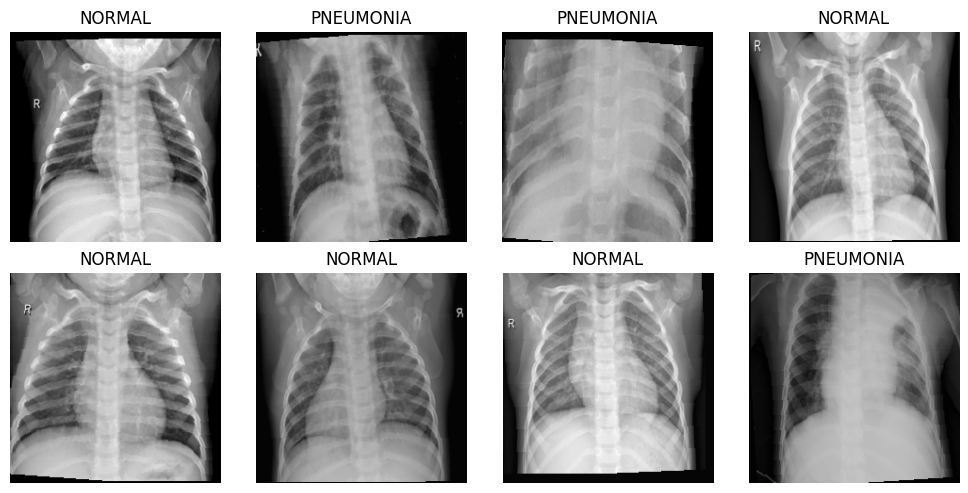

In [5]:
!pip -q install kagglehub scikit-learn

import os, time, json, random
from pathlib import Path
import numpy as np
import pandas as pd
from PIL import Image, UnidentifiedImageError
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader

from torchvision import transforms, models
from torchvision.models import DenseNet121_Weights, MobileNet_V2_Weights

from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, f1_score, recall_score, classification_report, confusion_matrix

import kagglehub

# -------------------------
# Configuración reproducible
# -------------------------
SEED = 42

def set_seed(seed=SEED):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)

set_seed(SEED)
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", DEVICE)

# -------------------------
# Descargar dataset
# -------------------------
path = kagglehub.dataset_download("paultimothymooney/chest-xray-pneumonia")
DATASET_ROOT = Path(path)
print("Path to dataset files:", DATASET_ROOT)

# -------------------------
# Helpers para filtrar basura de macOS y archivos corruptos
# -------------------------
VALID_EXTENSIONS = {".jpeg", ".jpg", ".png"}

def is_valid_candidate_file(p: Path):
    parts = set(p.parts)

    # Excluir carpetas basura de macOS
    if "__MACOSX" in parts:
        return False

    # Excluir archivos tipo ._xxxx
    if p.name.startswith("._"):
        return False

    # Excluir ocultos
    if p.name.startswith("."):
        return False

    # Excluir extensiones no válidas
    if p.suffix.lower() not in VALID_EXTENSIONS:
        return False

    return True

def is_readable_image(p: Path):
    try:
        with Image.open(p) as img:
            img.verify()  # verifica integridad sin cargar completa
        return True
    except Exception:
        return False

# -------------------------
# Recolectar todas las imágenes válidas
# -------------------------
def collect_all_images(root: Path):
    rows = []
    invalid_files = []

    for class_name in ["NORMAL", "PNEUMONIA"]:
        for img_path in root.rglob(f"{class_name}/*"):
            if not img_path.is_file():
                continue

            if not is_valid_candidate_file(img_path):
                continue

            if not is_readable_image(img_path):
                invalid_files.append(str(img_path))
                continue

            rows.append({
                "filepath": str(img_path),
                "label": 0 if class_name == "NORMAL" else 1,
                "class_name": class_name
            })

    df = pd.DataFrame(rows).drop_duplicates().reset_index(drop=True)

    print(f"\nTotal imágenes válidas: {len(df)}")
    print(f"Archivos inválidos/corruptos filtrados: {len(invalid_files)}")

    if len(invalid_files) > 0:
        print("\nEjemplos de archivos filtrados:")
        for x in invalid_files[:10]:
            print(x)

    return df

df = collect_all_images(DATASET_ROOT)

print("\nConteo por clase:")
print(df["class_name"].value_counts())

# -------------------------
# División 70/15/15 estratificada
# -------------------------
train_df, temp_df = train_test_split(
    df,
    test_size=0.30,
    stratify=df["label"],
    random_state=SEED
)

val_df, test_df = train_test_split(
    temp_df,
    test_size=0.50,
    stratify=temp_df["label"],
    random_state=SEED
)

print("\nTamaños:")
print("Train:", len(train_df), "| Val:", len(val_df), "| Test:", len(test_df))

print("\nDistribución train:")
print(train_df["label"].value_counts(normalize=True))

print("\nDistribución val:")
print(val_df["label"].value_counts(normalize=True))

print("\nDistribución test:")
print(test_df["label"].value_counts(normalize=True))

# -------------------------
# Transforms
# -------------------------
imagenet_mean = [0.485, 0.456, 0.406]
imagenet_std = [0.229, 0.224, 0.225]

train_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandomHorizontalFlip(p=0.3),
    transforms.RandomRotation(degrees=7),
    transforms.RandomAffine(degrees=0, translate=(0.03, 0.03), scale=(0.97, 1.03)),
    transforms.ColorJitter(brightness=0.08, contrast=0.08),
    transforms.Grayscale(num_output_channels=3),
    transforms.ToTensor(),
    transforms.Normalize(mean=imagenet_mean, std=imagenet_std)
])

eval_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.Grayscale(num_output_channels=3),
    transforms.ToTensor(),
    transforms.Normalize(mean=imagenet_mean, std=imagenet_std)
])

# -------------------------
# Dataset y DataLoaders
# -------------------------
class XRayDataset(Dataset):
    def __init__(self, dataframe, transform=None):
        self.dataframe = dataframe.reset_index(drop=True)
        self.transform = transform

    def __len__(self):
        return len(self.dataframe)

    def __getitem__(self, idx):
        row = self.dataframe.iloc[idx]
        image_path = row["filepath"]
        label = int(row["label"])

        try:
            image = Image.open(image_path).convert("RGB")
        except (UnidentifiedImageError, OSError):
            # fallback defensivo por si apareciera algo raro no detectado antes
            # intenta cargar otra imagen válida
            new_idx = (idx + 1) % len(self.dataframe)
            row = self.dataframe.iloc[new_idx]
            image = Image.open(row["filepath"]).convert("RGB")
            label = int(row["label"])

        if self.transform:
            image = self.transform(image)

        return image, label

BATCH_SIZE = 32

train_dataset = XRayDataset(train_df, transform=train_transform)
val_dataset = XRayDataset(val_df, transform=eval_transform)
test_dataset = XRayDataset(test_df, transform=eval_transform)

# En Colab a veces es más estable arrancar con num_workers=0
train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True, num_workers=0, pin_memory=True)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=0, pin_memory=True)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=0, pin_memory=True)

# -------------------------
# Visualización rápida
# -------------------------
images, labels = next(iter(train_loader))

fig, axes = plt.subplots(2, 4, figsize=(10, 5))
axes = axes.flatten()

for i in range(8):
    img = images[i].permute(1, 2, 0).numpy()
    img = img * np.array(imagenet_std) + np.array(imagenet_mean)
    img = np.clip(img, 0, 1)
    axes[i].imshow(img)
    axes[i].set_title("PNEUMONIA" if labels[i].item() == 1 else "NORMAL")
    axes[i].axis("off")

plt.tight_layout()
plt.show()

In [7]:
# -------------------------
# Modelos
# -------------------------
def build_densenet121(num_classes=1, freeze_features=True):
    model = models.densenet121(weights=DenseNet121_Weights.DEFAULT)
    if freeze_features:
        for param in model.features.parameters():
            param.requires_grad = False
    in_features = model.classifier.in_features
    model.classifier = nn.Sequential(
        nn.Dropout(0.3),
        nn.Linear(in_features, num_classes)
    )
    return model

def build_mobilenetv2(num_classes=1, freeze_features=True):
    model = models.mobilenet_v2(weights=MobileNet_V2_Weights.DEFAULT)
    if freeze_features:
        for param in model.features.parameters():
            param.requires_grad = False
    in_features = model.classifier[1].in_features
    model.classifier = nn.Sequential(
        nn.Dropout(0.3),
        nn.Linear(in_features, num_classes)
    )
    return model

# -------------------------
# Hiperparámetros
# -------------------------
LR = 1e-3
EPOCHS = 12
PATIENCE = 3
criterion = nn.BCEWithLogitsLoss()

# -------------------------
# Funciones de entrenamiento/evaluación
# -------------------------
def train_one_epoch(model, loader, optimizer, device):
    model.train()
    running_loss = 0.0
    y_true, y_pred = [], []

    for images, labels in loader:
        images = images.to(device)
        labels = labels.float().unsqueeze(1).to(device)

        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item() * images.size(0)

        probs = torch.sigmoid(outputs)
        preds = (probs >= 0.5).int().cpu().numpy().ravel()
        y_pred.extend(preds)
        y_true.extend(labels.int().cpu().numpy().ravel())

    return (
        running_loss / len(loader.dataset),
        accuracy_score(y_true, y_pred),
        f1_score(y_true, y_pred, pos_label=1)
    )

@torch.no_grad()
def evaluate(model, loader, device):
    model.eval()
    running_loss = 0.0
    y_true, y_pred, y_prob = [], [], []

    for images, labels in loader:
        images = images.to(device)
        labels = labels.float().unsqueeze(1).to(device)

        outputs = model(images)
        loss = criterion(outputs, labels)
        running_loss += loss.item() * images.size(0)

        probs = torch.sigmoid(outputs)
        preds = (probs >= 0.5).int().cpu().numpy().ravel()

        y_prob.extend(probs.cpu().numpy().ravel())
        y_pred.extend(preds)
        y_true.extend(labels.int().cpu().numpy().ravel())

    return (
        running_loss / len(loader.dataset),
        accuracy_score(y_true, y_pred),
        f1_score(y_true, y_pred, pos_label=1),
        recall_score(y_true, y_pred, pos_label=1),
        np.array(y_true),
        np.array(y_pred),
        np.array(y_prob)
    )

def train_model(model, train_loader, val_loader, model_name, lr=LR, epochs=EPOCHS, patience=PATIENCE):
    model = model.to(DEVICE)
    optimizer = optim.Adam(filter(lambda p: p.requires_grad, model.parameters()), lr=lr)

    best_val_loss = float("inf")
    patience_counter = 0
    best_path = f"{model_name}_best.pth"
    history = []

    for epoch in range(1, epochs + 1):
        train_loss, train_acc, train_f1 = train_one_epoch(model, train_loader, optimizer, DEVICE)
        val_loss, val_acc, val_f1, val_recall, _, _, _ = evaluate(model, val_loader, DEVICE)

        history.append({
            "epoch": epoch,
            "train_loss": train_loss,
            "train_acc": train_acc,
            "train_f1": train_f1,
            "val_loss": val_loss,
            "val_acc": val_acc,
            "val_f1": val_f1,
            "val_recall": val_recall
        })

        print(
            f"[{model_name}] Epoch {epoch:02d} | "
            f"train_loss={train_loss:.4f} train_acc={train_acc:.4f} train_f1={train_f1:.4f} | "
            f"val_loss={val_loss:.4f} val_acc={val_acc:.4f} val_f1={val_f1:.4f} val_recall={val_recall:.4f}"
        )

        if val_loss < best_val_loss:
            best_val_loss = val_loss
            torch.save(model.state_dict(), best_path)
            patience_counter = 0
        else:
            patience_counter += 1
            if patience_counter >= patience:
                print(f"Early stopping activado para {model_name} en la época {epoch}.")
                break

    model.load_state_dict(torch.load(best_path, map_location=DEVICE))
    return model, pd.DataFrame(history), best_path

# -------------------------
# Entrenar ambos modelos
# -------------------------
densenet_model = build_densenet121(freeze_features=True)
mobilenet_model = build_mobilenetv2(freeze_features=True)

densenet_model, densenet_history, densenet_path = train_model(
    densenet_model, train_loader, val_loader, "DenseNet121"
)

mobilenet_model, mobilenet_history, mobilenet_path = train_model(
    mobilenet_model, train_loader, val_loader, "MobileNetV2"
)

[DenseNet121] Epoch 01 | train_loss=0.3618 train_acc=0.8498 train_f1=0.9036 | val_loss=0.2410 val_acc=0.9124 val_f1=0.9416 val_recall=0.9680
[DenseNet121] Epoch 02 | train_loss=0.2557 train_acc=0.8983 train_f1=0.9317 | val_loss=0.2121 val_acc=0.9266 val_f1=0.9493 val_recall=0.9415
[DenseNet121] Epoch 03 | train_loss=0.2297 train_acc=0.9097 train_f1=0.9390 | val_loss=0.1936 val_acc=0.9283 val_f1=0.9508 val_recall=0.9493
[DenseNet121] Epoch 04 | train_loss=0.2254 train_acc=0.9094 train_f1=0.9387 | val_loss=0.1840 val_acc=0.9277 val_f1=0.9511 val_recall=0.9633
[DenseNet121] Epoch 05 | train_loss=0.2103 train_acc=0.9157 train_f1=0.9429 | val_loss=0.1792 val_acc=0.9311 val_f1=0.9529 val_recall=0.9540
[DenseNet121] Epoch 06 | train_loss=0.2142 train_acc=0.9138 train_f1=0.9416 | val_loss=0.2166 val_acc=0.9180 val_f1=0.9417 val_recall=0.9080
[DenseNet121] Epoch 07 | train_loss=0.2096 train_acc=0.9129 train_f1=0.9409 | val_loss=0.1721 val_acc=0.9334 val_f1=0.9545 val_recall=0.9563
[DenseNet121]


===== DenseNet121 =====
Confusion Matrix:
[[ 425   50]
 [  57 1225]]

Classification Report:
              precision    recall  f1-score   support

      NORMAL       0.88      0.89      0.89       475
   PNEUMONIA       0.96      0.96      0.96      1282

    accuracy                           0.94      1757
   macro avg       0.92      0.93      0.92      1757
weighted avg       0.94      0.94      0.94      1757


===== MobileNetV2 =====
Confusion Matrix:
[[ 435   40]
 [  56 1226]]

Classification Report:
              precision    recall  f1-score   support

      NORMAL       0.89      0.92      0.90       475
   PNEUMONIA       0.97      0.96      0.96      1282

    accuracy                           0.95      1757
   macro avg       0.93      0.94      0.93      1757
weighted avg       0.95      0.95      0.95      1757



,model,accuracy_percent,f1_percent,recall_percent,size_mb,avg_inference_ms_100imgs,images_per_second,images_per_hour,mb_per_f1_point
0,DenseNet121,93.910074,95.815409,95.553822,27.114096,15.036273,66.505840,239421.024578,0.282983
1,MobileNetV2,94.536141,96.232339,95.631825,8.724376,8.004656,124.927295,449738.261890,0.090659


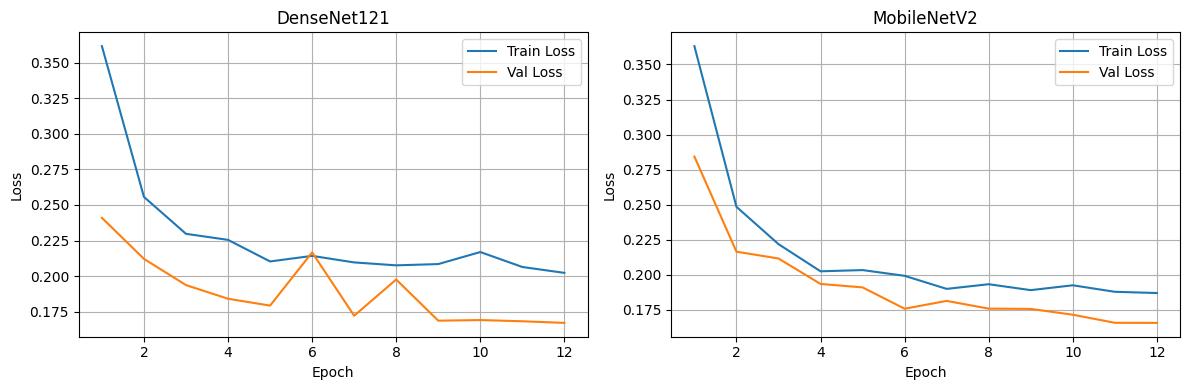

In [8]:
@torch.no_grad()
def average_inference_time_ms(model, loader, device, n_images=100):
    model.eval()
    total_time = 0.0
    count = 0

    for images, _ in loader:
        for i in range(images.size(0)):
            if count >= n_images:
                return (total_time / count) * 1000

            x = images[i:i+1].to(device)

            if device.type == "cuda":
                torch.cuda.synchronize()
            start = time.perf_counter()
            _ = model(x)
            if device.type == "cuda":
                torch.cuda.synchronize()
            end = time.perf_counter()

            total_time += (end - start)
            count += 1

    return (total_time / count) * 1000

def model_size_mb(path):
    return os.path.getsize(path) / (1024 * 1024)

def evaluate_on_test(model, loader, model_path, model_name):
    test_loss, acc, f1, recall, y_true, y_pred, _ = evaluate(model, loader, DEVICE)
    inf_ms = average_inference_time_ms(model, loader, DEVICE, n_images=100)
    size_mb = model_size_mb(model_path)

    print(f"\n===== {model_name} =====")
    print("Confusion Matrix:")
    print(confusion_matrix(y_true, y_pred))
    print("\nClassification Report:")
    print(classification_report(y_true, y_pred, target_names=["NORMAL", "PNEUMONIA"]))

    return {
        "model": model_name,
        "test_loss": test_loss,
        "accuracy": acc,
        "f1_pneumonia": f1,
        "recall_pneumonia": recall,
        "size_mb": size_mb,
        "avg_inference_ms_100imgs": inf_ms
    }

densenet_results = evaluate_on_test(densenet_model, test_loader, densenet_path, "DenseNet121")
mobilenet_results = evaluate_on_test(mobilenet_model, test_loader, mobilenet_path, "MobileNetV2")

results_df = pd.DataFrame([densenet_results, mobilenet_results])
results_df["accuracy_percent"] = results_df["accuracy"] * 100
results_df["f1_percent"] = results_df["f1_pneumonia"] * 100
results_df["recall_percent"] = results_df["recall_pneumonia"] * 100
results_df["mb_per_f1_point"] = results_df["size_mb"] / results_df["f1_percent"]
results_df["images_per_second"] = 1000 / results_df["avg_inference_ms_100imgs"]
results_df["images_per_hour"] = results_df["images_per_second"] * 3600

display(results_df[[
    "model",
    "accuracy_percent",
    "f1_percent",
    "recall_percent",
    "size_mb",
    "avg_inference_ms_100imgs",
    "images_per_second",
    "images_per_hour",
    "mb_per_f1_point"
]])

# Curvas de loss
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(densenet_history["epoch"], densenet_history["train_loss"], label="Train Loss")
axes[0].plot(densenet_history["epoch"], densenet_history["val_loss"], label="Val Loss")
axes[0].set_title("DenseNet121")
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("Loss")
axes[0].legend()
axes[0].grid(True)

axes[1].plot(mobilenet_history["epoch"], mobilenet_history["train_loss"], label="Train Loss")
axes[1].plot(mobilenet_history["epoch"], mobilenet_history["val_loss"], label="Val Loss")
axes[1].set_title("MobileNetV2")
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("Loss")
axes[1].legend()
axes[1].grid(True)

plt.tight_layout()
plt.show()

# Dictamen ejecutivo

## 1. Tabla comparativa de modelos

Con base en los experimentos realizados sobre el conjunto de prueba, se obtuvo la siguiente comparación entre **DenseNet121** y **MobileNetV2**:

| Modelo | Accuracy (%) | F1 Pneumonia (%) | Recall Pneumonia (%) | Tamaño (MB) | Inferencia promedio (ms/imagen) | Imágenes por segundo | Imágenes por hora | MB por punto de F1 |
|---|---:|---:|---:|---:|---:|---:|---:|---:|
| DenseNet121 | 93.91 | 95.82 | 95.55 | 27.11 | 15.04 | 66.51 | 239,421 | 0.283 |
| MobileNetV2 | 94.54 | 96.23 | 95.63 | 8.72 | 8.00 | 124.93 | 449,738 | 0.091 |

A partir de esta tabla puede observarse que ambos modelos alcanzaron un desempeño alto en la tarea de clasificación binaria entre radiografías normales y radiografías con neumonía. Sin embargo, **MobileNetV2 superó ligeramente a DenseNet121 no solo en eficiencia computacional, sino también en desempeño predictivo**.

---

## 2. Análisis de Sensibilidad vs. Accuracy

En un problema clínico como este, la métrica de mayor interés no es únicamente la **Accuracy**, sino especialmente la **Sensibilidad o Recall para la clase Pneumonia**. Esto se debe a que la Sensibilidad mide qué proporción de pacientes con neumonía fue detectada correctamente por el modelo.

En los resultados obtenidos:

- **DenseNet121** alcanzó un Recall para Pneumonia de **95.55%**
- **MobileNetV2** alcanzó un Recall para Pneumonia de **95.63%**

La diferencia es pequeña, pero favorece a **MobileNetV2**. Esto significa que, dentro del conjunto de prueba, MobileNetV2 dejó pasar ligeramente menos casos positivos que DenseNet121.

La razón por la que en medicina suele preferirse una **Sensibilidad alta**, incluso si eso implica sacrificar algo de Accuracy, es que el costo de un **falso negativo** puede ser mucho más grave que el de un falso positivo. En este contexto, un falso negativo representa una radiografía con neumonía que el sistema clasifica como normal. Ese error podría retrasar la revisión clínica, el tratamiento y la atención del paciente. En cambio, un falso positivo normalmente implica una revisión adicional, lo cual también tiene costo, pero suele ser menos riesgoso que omitir un caso real.

Por tanto, en un sistema de apoyo al diagnóstico, conviene priorizar modelos que mantengan una detección alta de neumonía, aun si la Accuracy global no fuera la máxima posible. En este experimento, ambos modelos lograron un Recall alto, lo cual es positivo, pero **MobileNetV2 mostró el mejor equilibrio entre Sensibilidad, Accuracy y F1**.

---

## 3. ¿Qué modelo detecta mejor neumonía?

Si se toma únicamente la capacidad de detección de neumonía, ambos modelos son fuertes, pero **MobileNetV2 presentó una ventaja ligera**:

- tuvo mejor **Recall** para la clase positiva
- tuvo mejor **F1-score** para la clase positiva
- tuvo mejor **Accuracy global**

El **F1-score** también es importante porque combina precisión y recall, por lo que refleja mejor el equilibrio del modelo frente a la clase de interés. En este caso:

- **DenseNet121:** F1 Pneumonia = **95.82%**
- **MobileNetV2:** F1 Pneumonia = **96.23%**

Esto refuerza la idea de que MobileNetV2 no solo detectó bien los positivos, sino que mantuvo un mejor balance general en sus predicciones.

---

## 4. Recomendación final al CTO para producción on-premise sin GPU

Con base en los resultados obtenidos, la recomendación al CTO sería **usar MobileNetV2 para producción on-premise sin GPU**.

La justificación es sólida desde dos perspectivas:

### Perspectiva clínica
MobileNetV2 obtuvo:
- mejor Accuracy
- mejor F1 para neumonía
- mejor Recall para neumonía

Es decir, no solo fue más eficiente, sino también ligeramente mejor detectando casos positivos.

### Perspectiva operativa
MobileNetV2 además resultó mucho más conveniente para un entorno con hardware limitado:

- **8.72 MB** frente a **27.11 MB** de DenseNet121
- **8.00 ms** por imagen frente a **15.04 ms** de DenseNet121
- aproximadamente **124.93 imágenes por segundo**, frente a **66.51** de DenseNet121

Esto significa que MobileNetV2 ocupa mucho menos espacio en disco, requiere menos recursos para inferencia y ofrece mayor velocidad de procesamiento. Para clínicas rurales, computadoras locales modestas o despliegues sin aceleración por GPU, esta diferencia es muy valiosa.

Por tanto, dado que MobileNetV2 fue **más ligero, más rápido y además ligeramente mejor en desempeño clínico**, se considera la opción más razonable para producción.

---

## 5. Reflexión sobre limitaciones del experimento

Aunque los resultados son prometedores, el experimento presenta varias limitaciones importantes que deben reconocerse antes de pensar en un despliegue real.

En primer lugar, se trabajó con un **dataset público**, no con datos recolectados directamente en hospitales de Guatemala. Esto implica que la distribución de las imágenes, la calidad radiográfica, los equipos de adquisición y las características de la población pueden no representar fielmente el contexto real donde MediScan Guatemala operaría.

En segundo lugar, el problema se formuló como una tarea **binaria simplificada**: normal vs. neumonía. En la práctica clínica, una radiografía puede contener otros hallazgos relevantes, patologías simultáneas o variaciones anatómicas que no están capturadas en este experimento.

En tercer lugar, aunque se aplicó una división estratificada y una evaluación en test, no se realizó una **validación externa multi-hospital**, que sería necesaria para estimar generalización real. Tampoco se evaluó calibración de probabilidades, incertidumbre del modelo ni robustez ante cambios de dominio.

En consecuencia, estos resultados deben interpretarse como una evidencia inicial útil para comparar arquitecturas, pero no como una validación clínica definitiva.

---

## 6. ¿Cuánto “cuesta” en MB cada punto porcentual de F1?

La relación entre tamaño del modelo y desempeño puede analizarse con la métrica **MB por punto porcentual de F1**:

- **DenseNet121:** 0.283 MB por punto de F1
- **MobileNetV2:** 0.091 MB por punto de F1

Esto significa que **MobileNetV2 entrega más rendimiento por cada MB invertido**. En otras palabras, cada punto porcentual de F1 “cuesta” mucho menos almacenamiento en MobileNetV2 que en DenseNet121.

En el contexto de clínicas rurales o instalaciones con hardware limitado, esta diferencia sí importa. Si un modelo más pesado ofreciera una mejora clínicamente muy grande, podría justificarse. Pero en este caso ocurre lo contrario: el modelo más pesado no mejora el F1, sino que incluso queda ligeramente por debajo del modelo más liviano.

Por ello, **no parece valer la pena elegir el modelo más pesado** en este escenario. Desde una perspectiva costo-beneficio, MobileNetV2 ofrece una mejor relación entre tamaño, velocidad y desempeño.

---

## 7. ¿El tiempo de inferencia es aceptable en un flujo clínico real?

Sí, el tiempo de inferencia observado es más que aceptable para un flujo clínico real, al menos desde la perspectiva estrictamente algorítmica.

Los resultados indican:

- **DenseNet121:** alrededor de **15.04 ms por imagen**
- **MobileNetV2:** alrededor de **8.00 ms por imagen**

Traducido a capacidad operativa aproximada:

- DenseNet121 podría procesar cerca de **239,421 imágenes por hora**
- MobileNetV2 podría procesar cerca de **449,738 imágenes por hora**

Estas cifras muestran que la inferencia del modelo no sería el cuello de botella principal. En un entorno real, el tiempo total del flujo clínico dependerá más de otros factores, como:

- carga y lectura de la imagen desde el sistema hospitalario
- preprocesamiento
- transferencia de archivos
- integración con PACS o HIS
- validación o revisión por personal médico

Por tanto, desde el punto de vista del modelo, la velocidad es totalmente suficiente para operar en tiempo real o casi en tiempo real. Incluso el modelo más lento del experimento sigue siendo extremadamente rápido para una radiografía individual.

---

## 8. Reflexión sobre congelar vs. descongelar capas

En este experimento se utilizó una estrategia de **Transfer Learning con capas base congeladas** y un cabezal nuevo para clasificación binaria. Esta decisión fue coherente con el tamaño del dataset y con lo analizado conceptualmente en el Task 2.

Al congelar las capas base, se aprovechan las representaciones visuales generales aprendidas durante el preentrenamiento en ImageNet y se reduce el número de parámetros que deben ajustarse con un dataset relativamente pequeño. Esto disminuye el riesgo de sobreajuste y hace el entrenamiento más estable.

Las curvas de pérdida observadas muestran un comportamiento razonable: tanto DenseNet121 como MobileNetV2 redujeron la pérdida de entrenamiento y validación sin señales graves de divergencia. MobileNetV2, además, mostró una validación bastante estable hacia el final. Esto sugiere que, para este tamaño de muestra, la estrategia de congelar la base fue adecuada.

Si se hubiera descongelado toda la red desde el inicio con una tasa de aprendizaje alta, el entrenamiento podría haberse vuelto más inestable y habría aumentado el riesgo de **olvido catastrófico**, es decir, la destrucción rápida de características útiles aprendidas en el preentrenamiento. Por eso, la práctica observada en este notebook coincide con la lógica discutida en el análisis conceptual: **con pocos datos, conviene empezar de forma conservadora**.

---

## 9. ¿Funcionaría igual con radiografías de equipos distintos, poblaciones distintas o distintos hospitales?

No debe asumirse que el modelo funcionará igual en todos los entornos. Un modelo que rinde bien en este dataset puede perder desempeño cuando se enfrenta a imágenes provenientes de:

- equipos radiológicos distintos
- protocolos de adquisición diferentes
- poblaciones con otras características demográficas
- hospitales con variaciones en calidad de imagen o prevalencia de enfermedad

Esto se conoce como **cambio de dominio** o *domain shift*. En visión médica, este problema es especialmente importante porque pequeñas diferencias en contraste, posicionamiento, compresión, resolución o población pueden afectar significativamente el comportamiento del modelo.

Para MediScan Guatemala, esto tiene implicaciones claras. Antes de desplegar el sistema en hospitales reales, sería necesario:

- validar el modelo con datos locales
- probarlo en más de una institución
- medir desempeño por hospital o por equipo
- recalibrar o ajustar el modelo si aparecen caídas de rendimiento
- mantener supervisión clínica continua

En otras palabras, el hecho de que el modelo funcione bien en este experimento no garantiza automáticamente que funcionará igual en la práctica clínica guatemalteca. La validación externa es indispensable.

---

## 10. Conclusión

Los dos modelos evaluados alcanzaron resultados altos en la tarea de detección de neumonía en radiografías de tórax. Sin embargo, **MobileNetV2 fue la mejor opción global**.

No solo logró:

- mejor Accuracy
- mejor F1 para la clase Pneumonia
- mejor Recall para la clase Pneumonia

sino que además fue:

- mucho más pequeño
- notablemente más rápido
- más conveniente para despliegue en hardware limitado

Por ello, para una solución como MediScan Guatemala orientada a producción on-premise sin GPU, **se recomienda MobileNetV2 como primera opción de despliegue**.

Aun así, antes de una implementación real, sería indispensable realizar validación externa con datos locales, pruebas multi-hospital y revisión clínica rigurosa para asegurar que el sistema conserve su utilidad y seguridad fuera del entorno experimental.